In [235]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
print("Everything is working!")

Everything is working!


In [236]:
survey_2014 = pd.read_csv("survey_2014.csv")

In [237]:
print("2014:", survey_2014.shape)

2014: (1260, 27)


In [238]:
survey_2014.head()

,Timestamp,Age,Gender,Country,"If you live in the United States, which state or territory do you live in?",Are you self-employed?,Do you have a family history of mental illness?,Have you sought treatment for a mental health condition?,"If you have a mental health condition, do you feel that it interferes with your work?",How many employees does your company or organization have?,...,How easy is it for you to take medical leave for a mental health condition?,Do you think that discussing a mental health issue with your employer would have negative consequences?,Do you think that discussing a physical health issue with your employer would have negative consequences?,Would you be willing to discuss a mental health issue with your coworkers?,Would you be willing to discuss a mental health issue with your direct supervisor(s)?,Would you bring up a mental health issue with a potential employer in an interview?,Would you bring up a physical health issue with a potential employer in an interview?,Do you feel that your employer takes mental health as seriously as physical health?,Have you heard of or observed negative consequences for coworkers with mental health conditions in your workplace?,Any additional notes or comments
0,8/27/2014 11:29:31,37,Female,United States,IL,NaN,No,Yes,Often,6-25,...,Somewhat easy,No,No,Some of them,Yes,No,Maybe,Yes,No,NaN
1,8/27/2014 11:29:37,44,M,United States,IN,NaN,No,No,Rarely,More than 1000,...,Don't know,Maybe,No,No,No,No,No,Don't know,No,NaN
2,8/27/2014 11:29:44,32,Male,Canada,NaN,NaN,No,No,Rarely,6-25,...,Somewhat difficult,No,No,Yes,Yes,Yes,Yes,No,No,NaN
3,8/27/2014 11:29:46,31,Male,United Kingdom,NaN,NaN,Yes,Yes,Often,26-100,...,Somewhat difficult,Yes,Yes,Some of them,No,Maybe,Maybe,No,Yes,NaN
4,8/27/2014 11:30:22,31,Male,United States,TX,NaN,No,No,Never,100-500,...,Don't know,No,No,Some of them,Yes,Yes,Yes,Don't know,No,NaN


In [239]:
survey_2014.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1260 entries, 0 to 1259
Data columns (total 27 columns):
 #   Column                                                                                                                Non-Null Count  Dtype 
---  ------                                                                                                                --------------  ----- 
 0   Timestamp                                                                                                             1260 non-null   object
 1   Age                                                                                                                   1260 non-null   int64 
 2   Gender                                                                                                                1260 non-null   object
 3   Country                                                                                                               1260 non-null   object
 4   If you live 

In [240]:
survey_2014["Timestamp"] = pd.to_datetime(survey_2014["Timestamp"])

In [241]:
survey_2014["Gender"].value_counts()

Gender
Male                                              616
male                                              206
Female                                            121
M                                                 116
female                                             62
F                                                  38
m                                                  34
f                                                  15
Make                                                4
Male                                                3
Woman                                               3
Cis Male                                            2
Man                                                 2
Female                                              2
Female (trans)                                      2
Male-ish                                            1
Trans-female                                        1
Male (CIS)                                          1
Mal                  

In [242]:
gender_counts = survey_2014["Gender"].value_counts().reset_index()
gender_counts.columns = ["Gender", "Count"]

gender_counts

,Gender,Count
0,Male,616
1,male,206
2,Female,121
3,M,116
4,female,62
5,F,38
6,m,34
7,f,15
8,Make,4
9,Male,3


In [243]:
def clean_gender(gender):
    gender = str(gender).strip().lower()

    # Male values
    male = [
        "male", "m", "man", "cis male", "cis man",
        "male (cis)", "male-ish", "mal", "make",
        "maile", "mail", "malr", "msle",
        "guy (-ish) ^_^",
        "something kinda male?",
        "male leaning androgynous",
        "ostensibly male, unsure what that really means"
    ]

    # Female values
    female = [
        "female", "f", "woman",
        "cis female", "female (cis)",
        "female (trans)", "trans-female",
        "trans woman",
        "cis-female/femme",
        "femake", "femail"
    ]

    if gender in male:
        return "Male"
    elif gender in female:
        return "Female"
    else:
        return "Other"

In [244]:
survey_2014["Gender"] = survey_2014["Gender"].apply(clean_gender)
survey_2014["Gender"].value_counts()


Gender
Male      996
Female    251
Other      13
Name: count, dtype: int64

In [245]:
survey_2014["Age"].value_counts()

Age
 29             85
 32             82
 26             75
 27             71
 33             70
 28             68
 31             67
 34             65
 30             63
 25             61
 35             55
 23             51
 24             46
 37             43
 38             39
 36             37
 39             33
 40             33
 43             28
 41             22
 22             21
 42             20
 21             16
 45             12
 46             12
 44             11
 19              9
 18              7
 50              6
 48              6
 20              6
 51              5
 56              4
 49              4
 57              3
 55              3
 54              3
 47              2
 60              2
-29              1
 329             1
 99999999999     1
 58              1
 62              1
 65              1
-1726            1
 5               1
 53              1
 61              1
 8               1
 11              1
-1               1
 72     

In [246]:
survey_2014["Age"].describe()

count    1.260000e+03
mean     7.936511e+07
std      2.817181e+09
min     -1.726000e+03
25%      2.700000e+01
50%      3.100000e+01
75%      3.600000e+01
max      1.000000e+11
Name: Age, dtype: float64

In [247]:
survey_2014["Age"].sort_values(ascending=False).head(10)

390     99999999999
364             329
1182             72
560              65
520              62
952              61
1236             60
297              60
471              58
643              57
Name: Age, dtype: int64

In [248]:
invalid_age= survey_2014[(survey_2014["Age"]<18)| (survey_2014["Age"]>100)]
print("Invalid ages:",len(invalid_age))

Invalid ages: 8


In [249]:
# this is showing the unrealistic age
invalid_age = survey_2014[(survey_2014["Age"]<18)| (survey_2014["Age"]>100)]
invalid_age

,Timestamp,Age,Gender,Country,"If you live in the United States, which state or territory do you live in?",Are you self-employed?,Do you have a family history of mental illness?,Have you sought treatment for a mental health condition?,"If you have a mental health condition, do you feel that it interferes with your work?",How many employees does your company or organization have?,...,How easy is it for you to take medical leave for a mental health condition?,Do you think that discussing a mental health issue with your employer would have negative consequences?,Do you think that discussing a physical health issue with your employer would have negative consequences?,Would you be willing to discuss a mental health issue with your coworkers?,Would you be willing to discuss a mental health issue with your direct supervisor(s)?,Would you bring up a mental health issue with a potential employer in an interview?,Would you bring up a physical health issue with a potential employer in an interview?,Do you feel that your employer takes mental health as seriously as physical health?,Have you heard of or observed negative consequences for coworkers with mental health conditions in your workplace?,Any additional notes or comments
143,2014-08-27 12:39:15,-29,Male,United States,MN,No,No,No,NaN,More than 1000,...,Don't know,No,No,Some of them,Yes,No,No,Don't know,No,NaN
364,2014-08-27 15:05:21,329,Male,United States,OH,No,No,Yes,Often,6-25,...,Don't know,Maybe,No,Some of them,No,No,No,No,No,NaN
390,2014-08-27 15:24:47,99999999999,Other,Zimbabwe,NaN,Yes,Yes,Yes,Often,1-5,...,Very difficult,Yes,Yes,No,No,Yes,No,No,Yes,NaN
715,2014-08-28 10:07:53,-1726,Male,United Kingdom,NaN,No,No,Yes,Sometimes,26-100,...,Somewhat difficult,Yes,No,No,No,No,Maybe,Don't know,No,NaN
734,2014-08-28 10:35:56,5,Male,United States,OH,No,No,No,NaN,100-500,...,Somewhat easy,No,No,Yes,Yes,No,No,Yes,No,We had a developer suffer from depression and ...
989,2014-08-29 09:10:59,8,Other,"Bahamas, The",IL,Yes,Yes,Yes,Often,1-5,...,Very easy,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,
1090,2014-08-29 17:26:16,11,Male,United States,OH,Yes,No,No,Never,1-5,...,Very easy,No,No,Some of them,Some of them,No,Maybe,Yes,No,NaN
1127,2014-08-30 20:55:12,-1,Other,United States,AL,Yes,Yes,Yes,Often,1-5,...,Very easy,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,password: testered


In [250]:
# only ages within the age of 18-100 will be kept
survey_2014 = survey_2014[
          (survey_2014["Age"]>=18)&
          (survey_2014["Age"]<=100)]
print(survey_2014["Age"].min())
print(survey_2014["Age"].max())
print(survey_2014.shape)

18
72
(1252, 27)


In [251]:
#percentage of missing values
missing_percent = (survey_2014.isnull().sum()/len(survey_2014)) * 100
missing_summary = pd.DataFrame({
  "Missing Values": survey_2014.isnull().sum(),
  "percentage": missing_percent
})
missing_summary = missing_summary[missing_summary["Missing Values"]>0]
missing_summary.sort_values("percentage",ascending=False)

,Missing Values,percentage
Any additional notes or comments,1091,87.140575
"If you live in the United States, which state or territory do you live in?",514,41.054313
"If you have a mental health condition, do you feel that it interferes with your work?",262,20.926518
Are you self-employed?,18,1.437700


In [252]:
# the comment column has many blanks so it going to be dropped 
survey_2014.drop(
  columns=["Any additional notes or comments"],
  inplace = True
)


In [253]:
survey_2014.columns

Index(['Timestamp', 'Age', 'Gender', 'Country',
       'If you live in the United States, which state or territory do you live in?',
       'Are you self-employed?',
       'Do you have a family history of mental illness?',
       'Have you sought treatment for a mental health condition?',
       'If you have a mental health condition, do you feel that it interferes with your work?',
       'How many employees does your company or organization have?',
       'Do you work remotely (outside of an office) at least 50% of the time?',
       'Is your employer primarily a tech company/organization?',
       'Does your employer provide mental health benefits?',
       'Do you know the options for mental health care your employer provides?',
       'Has your employer ever discussed mental health as part of an employee wellness program?',
       'Does your employer provide resources to learn more about mental health issues and how to seek help?',
       'Is your anonymity protected if you choos

In [254]:
survey_2014["Are you self-employed?"].value_counts(dropna=False)

Are you self-employed?
No     1092
Yes     142
NaN      18
Name: count, dtype: int64

In [255]:
survey_2014["Are you self-employed?"].fillna(
    survey_2014["Are you self-employed?"].mode()[0],
    inplace=True
)

C:\Users\benso\AppData\Local\Temp\ipykernel_24196\4264196047.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  survey_2014["Are you self-employed?"].fillna(


In [256]:
survey_2014.drop_duplicates(inplace=True)

In [257]:
categorical_columns = survey_2014.select_dtypes(include="object").columns
for column in categorical_columns:
    print(f"\n{'='*60}")
    print(f"Column: {column}")
    print(f"{'='*60}")
    print(survey_2014[column].value_counts(dropna=False))


Column: Gender
Gender
Male      991
Female    251
Other      10
Name: count, dtype: int64

Column: Country
Country
United States             746
United Kingdom            184
Canada                     72
Germany                    45
Netherlands                27
Ireland                    27
Australia                  22
France                     13
India                      10
New Zealand                 8
Italy                       7
Switzerland                 7
Poland                      7
Sweden                      7
Brazil                      6
South Africa                6
Belgium                     6
Israel                      5
Singapore                   4
Bulgaria                    4
Russia                      3
Mexico                      3
Finland                     3
Austria                     3
Portugal                    2
Colombia                    2
Denmark                     2
Croatia                     2
Greece                      2
Costa Rica    

In [258]:
countries = sorted(survey_2014["Country"].unique())

for country in countries:
    print(country)

Australia
Austria
Belgium
Bosnia and Herzegovina
Brazil
Bulgaria
Canada
China
Colombia
Costa Rica
Croatia
Czech Republic
Denmark
Finland
France
Georgia
Germany
Greece
Hungary
India
Ireland
Israel
Italy
Japan
Latvia
Mexico
Moldova
Netherlands
New Zealand
Nigeria
Norway
Philippines
Poland
Portugal
Romania
Russia
Singapore
Slovenia
South Africa
Spain
Sweden
Switzerland
Thailand
United Kingdom
United States
Uruguay


In [259]:
survey_2014.to_csv("survey_2014_cleaned.csv", index=False)

# Exploratory Data Analysis (EDA)


### Section 1: Target Variable Analysis

In [260]:
survey_2014["Have you sought treatment for a mental health condition?"].value_counts()

Have you sought treatment for a mental health condition?
Yes    632
No     620
Name: count, dtype: int64

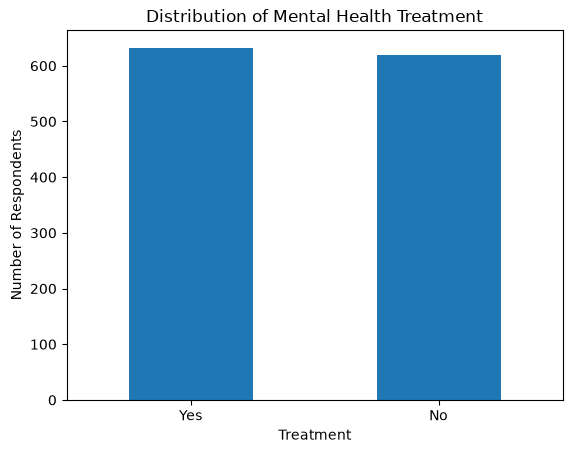

In [261]:
survey_2014["Have you sought treatment for a mental health condition?"]\
.value_counts()\
.plot(kind="bar")

plt.title("Distribution of Mental Health Treatment")
plt.xlabel("Treatment")
plt.ylabel("Number of Respondents")
plt.xticks(rotation=0)
plt.show()

The dataset is nearly balanced, with approximately half of the respondents reporting that they have sought treatment for a mental health condition. This balanced distribution is beneficial for building classification models because it reduces the risk of bias toward one class.

 ### Section 2: Demographic Analysis

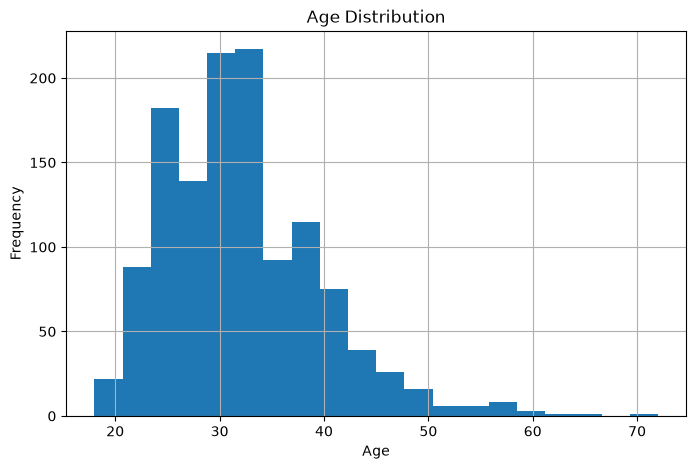

In [262]:
plt.figure(figsize=(8,5))

survey_2014["Age"].hist(bins=20)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

The respondents are relatively young, with an average age of approximately 32 years. Half of all respondents are between 27 and 36 years old, indicating that the survey primarily represents individuals in the early to mid stages of their careers. The age range spans from 18 to 72 years, showing participation from both younger and older professionals, although the majority are concentrated around their early thirties.

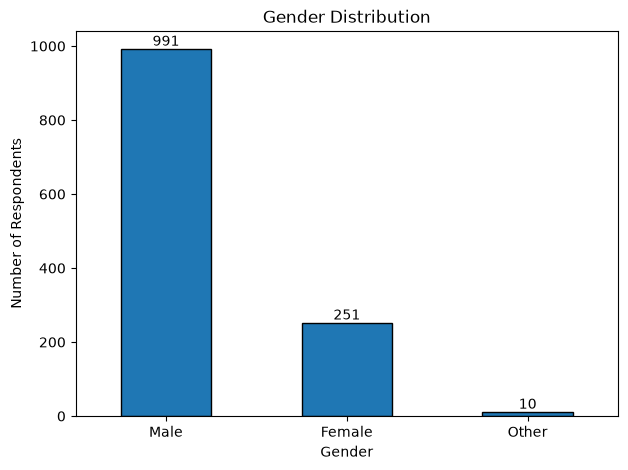

In [263]:
gender_counts = survey_2014["Gender"].value_counts()

ax = gender_counts.plot(
    kind="bar",
    figsize=(7,5),
    edgecolor="black"
)

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Number of Respondents")
plt.xticks(rotation=0)

# Add count labels
for i, value in enumerate(gender_counts):
    ax.text(i, value + 10, str(value), ha='center')

plt.show()

The majority of respondents identified as Male, accounting for approximately 79% of the dataset. Female respondents made up about 20%, while respondents identifying as Other represented less than 1%. This indicates that the survey population was predominantly male, reflecting the gender distribution commonly observed in the technology industry during the survey period.

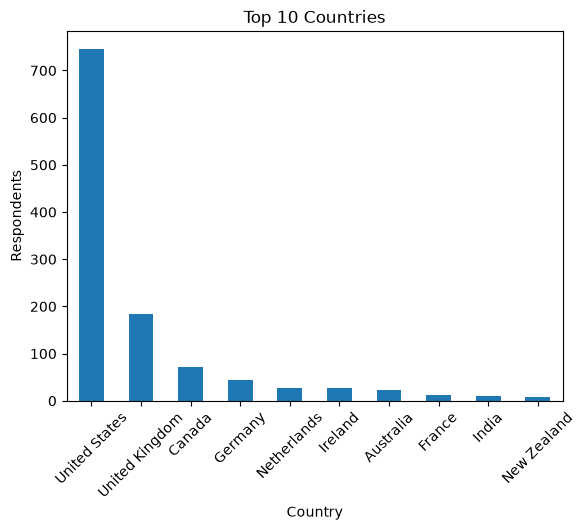

In [264]:
survey_2014["Country"].value_counts().head(10)
survey_2014["Country"]\
.value_counts()\
.head(10)\
.plot(kind="bar")

plt.title("Top 10 Countries")
plt.xlabel("Country")
plt.ylabel("Respondents")
plt.xticks(rotation=45)
plt.show()

<Axes: xlabel='Have you sought treatment for a mental health condition?', ylabel='Age'>

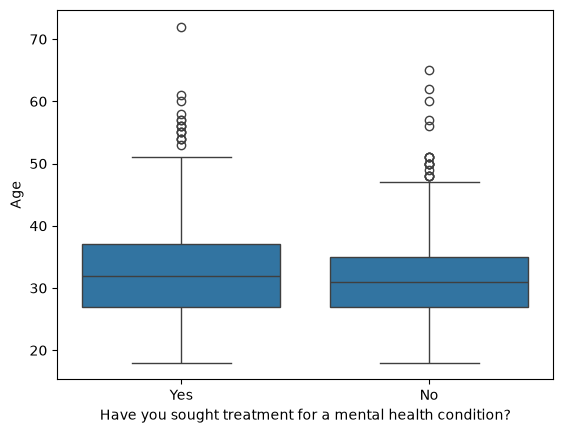

In [265]:
sns.boxplot(
    x="Have you sought treatment for a mental health condition?",
    y="Age",
    data=survey_2014
)

Respondents who sought treatment and those who did not have very similar age distributions. Age alone does not appear to strongly influence whether someone sought treatment.

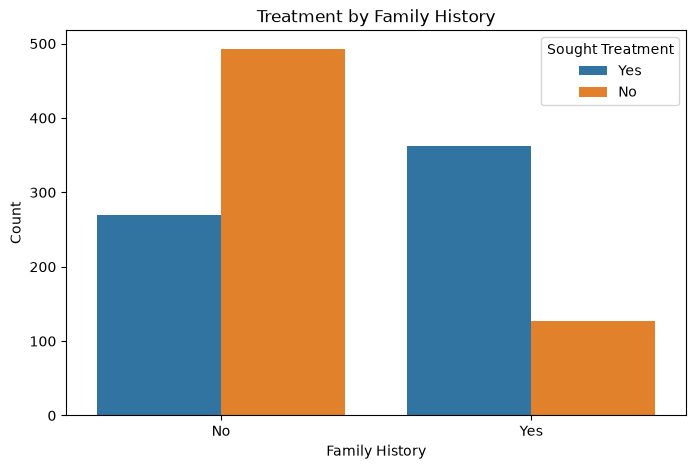

In [266]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=survey_2014,
    x="Do you have a family history of mental illness?",
    hue="Have you sought treatment for a mental health condition?"
)

plt.title("Treatment by Family History")
plt.xlabel("Family History")
plt.ylabel("Count")
plt.legend(title="Sought Treatment")

plt.show()

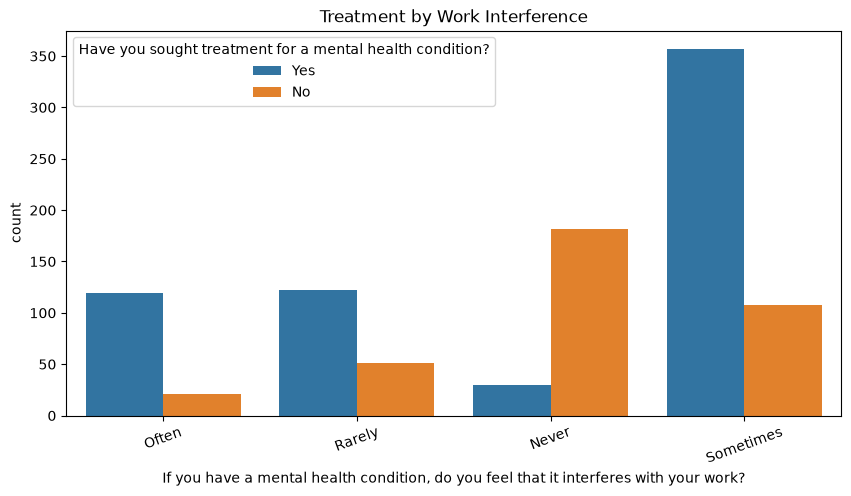

In [267]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=survey_2014,
    x="If you have a mental health condition, do you feel that it interferes with your work?",
    hue="Have you sought treatment for a mental health condition?"
)

plt.xticks(rotation=20)

plt.title("Treatment by Work Interference")

plt.show()

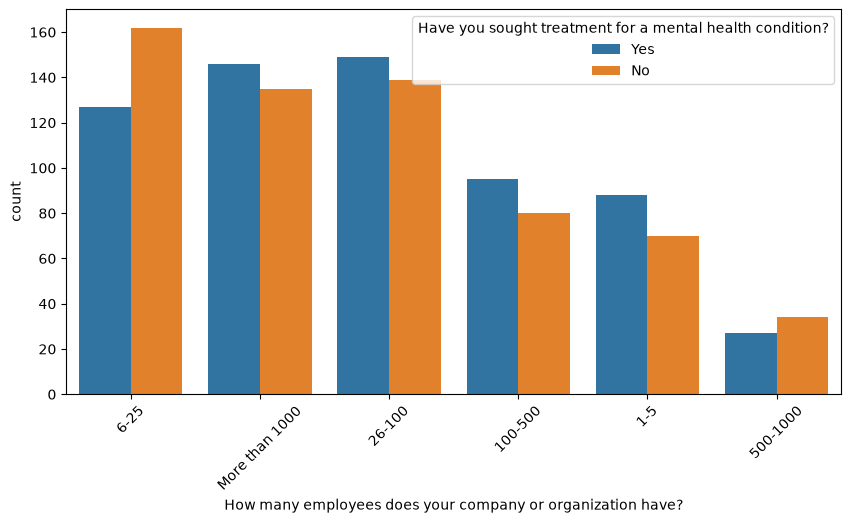

In [287]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=survey_2014,
    x="How many employees does your company or organization have?",
    hue="Have you sought treatment for a mental health condition?"
)

plt.xticks(rotation=45)

plt.show()

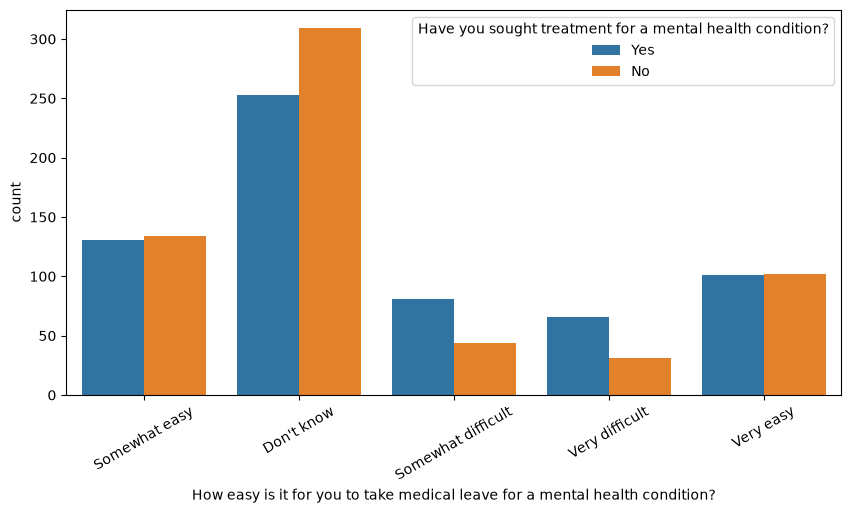

In [288]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=survey_2014,
    x="How easy is it for you to take medical leave for a mental health condition?",
    hue="Have you sought treatment for a mental health condition?"
)

plt.xticks(rotation=30)

plt.show()

## Correlation / Feature Importance

In [268]:
columns_to_drop = [
    "Timestamp",
    "If you live in the United States, which state or territory do you live in?"
]

survey_2014 = survey_2014.drop(columns=columns_to_drop)

In [269]:
target = "Have you sought treatment for a mental health condition?"

In [270]:
X = survey_2014.drop(columns=[target])
y = survey_2014[target]

In [271]:
X_encoded = X.copy()

le = LabelEncoder()

for col in X_encoded.columns:
    X_encoded[col] = le.fit_transform(X_encoded[col].astype(str))

y_encoded = le.fit_transform(y)

In [272]:
from sklearn.feature_selection import chi2

chi_scores, p_values = chi2(X_encoded, y_encoded)

In [273]:
chi_results = pd.DataFrame({
    "Feature": X.columns,
    "Chi2 Score": chi_scores,
    "P-value": p_values
})

chi_results = chi_results.sort_values(
    by="Chi2 Score",
    ascending=False
)

chi_results.head(10)

,Feature,Chi2 Score,P-value
4,Do you have a family history of mental illness?,108.484656,2.104734e-25
10,Do you know the options for mental health care...,54.852664,1.299126e-13
9,Does your employer provide mental health benef...,42.035591,8.962721e-11
2,Country,40.700259,1.774637e-10
13,Is your anonymity protected if you choose to t...,32.585762,1.140472e-08
22,Have you heard of or observed negative consequ...,24.122015,9.042067e-07
0,Age,23.670869,1.142996e-06
14,How easy is it for you to take medical leave f...,7.543104,6.024016e-03
1,Gender,7.095026,7.729817e-03
12,Does your employer provide resources to learn ...,5.234841,2.213883e-02


## Mutual Information (MI)

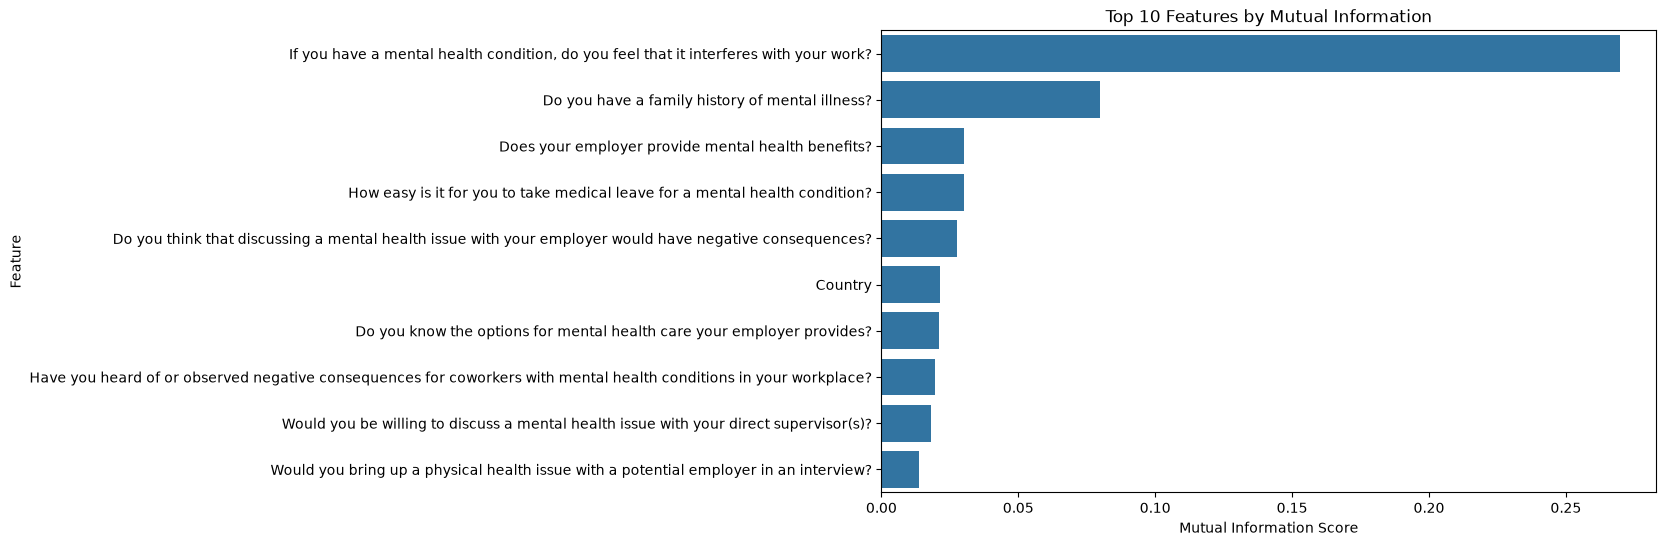

In [274]:
from sklearn.feature_selection import mutual_info_classif
mi_scores = mutual_info_classif(
    X_encoded,
    y_encoded,
    random_state=42
)

mi_results = pd.DataFrame({
    "Feature": X.columns,
    "Mutual Information": mi_scores
})

mi_results = mi_results.sort_values(
    by="Mutual Information",
    ascending=False
)

mi_results.head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    data=mi_results.head(10),
    x="Mutual Information",
    y="Feature"
)

plt.title("Top 10 Features by Mutual Information")
plt.xlabel("Mutual Information Score")
plt.ylabel("Feature")

plt.show()

## Random Forest Feature Importance

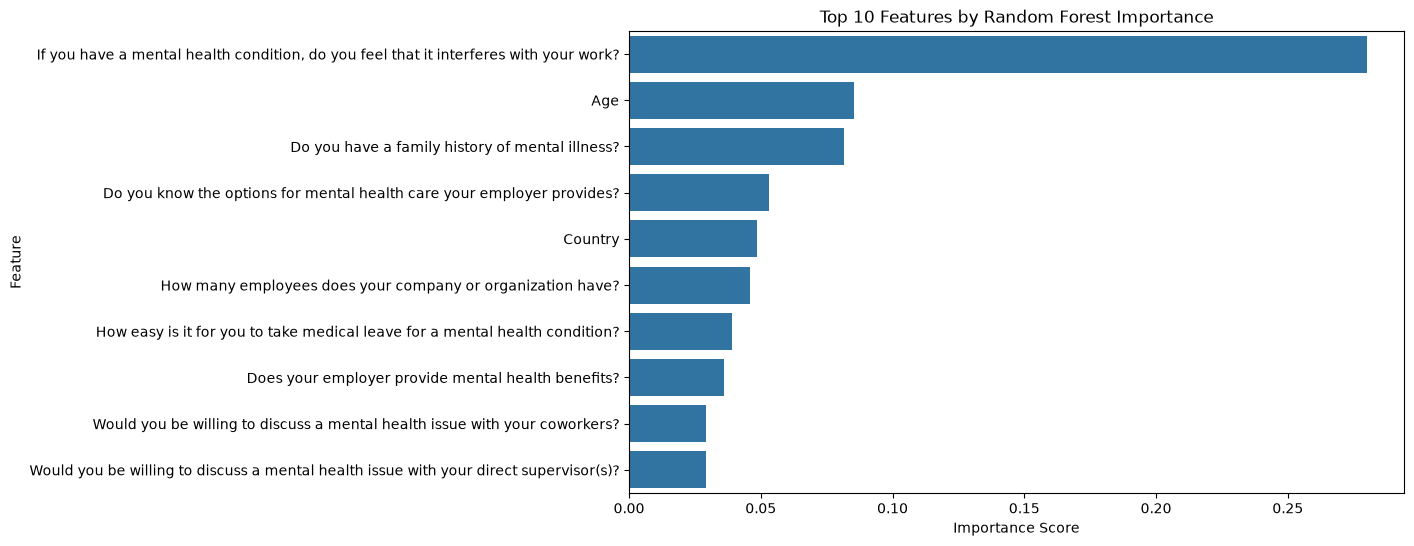

In [276]:
from sklearn.ensemble import RandomForestClassifier
# Train the model
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)
rf.fit(X_encoded, y_encoded)

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_encoded, y_encoded)
# Extract feature importance
rf_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

# Sort from highest to lowest
rf_importance = rf_importance.sort_values(
    by="Importance",
    ascending=False
)

# Display the top 10 features
rf_importance.head(10)
## plot
plt.figure(figsize=(10,6))

sns.barplot(
    data=rf_importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Features by Random Forest Importance")
plt.xlabel("Importance Score")
plt.ylabel("Feature")

plt.show()

## Mchine Learning

In [285]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)

print(X_train.shape)
print(X_test.shape)

print(y_train.shape)
print(y_test.shape)

(1001, 23)
(251, 23)
(1001,)
(251,)


Accuracy : 0.6972111553784861
Precision: 0.6946564885496184
Recall   : 0.7165354330708661
F1 Score : 0.7054263565891473
              precision    recall  f1-score   support

           0       0.70      0.68      0.69       124
           1       0.69      0.72      0.71       127

    accuracy                           0.70       251
   macro avg       0.70      0.70      0.70       251
weighted avg       0.70      0.70      0.70       251



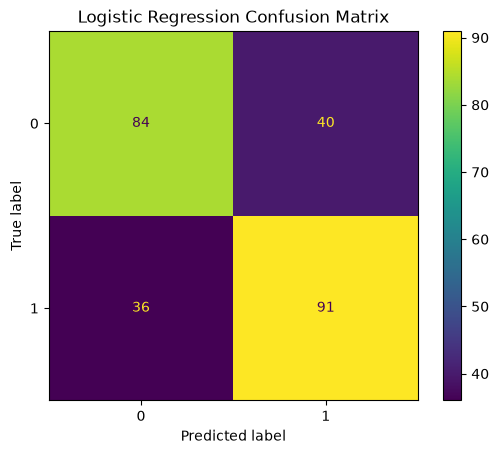

In [286]:
from sklearn.linear_model import LogisticRegression
log_model = LogisticRegression(max_iter=1000, random_state=42)

log_model.fit(X_train, y_train)

y_pred = log_model.predict(X_test)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

print(classification_report(y_test, y_pred))

from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(log_model, X_test, y_test)

plt.title("Logistic Regression Confusion Matrix")
plt.show()

# Decision Tree

Accuracy : 0.7729083665338645
Precision: 0.782258064516129
Recall   : 0.7637795275590551
F1 Score : 0.7729083665338645
              precision    recall  f1-score   support

           0       0.76      0.78      0.77       124
           1       0.78      0.76      0.77       127

    accuracy                           0.77       251
   macro avg       0.77      0.77      0.77       251
weighted avg       0.77      0.77      0.77       251



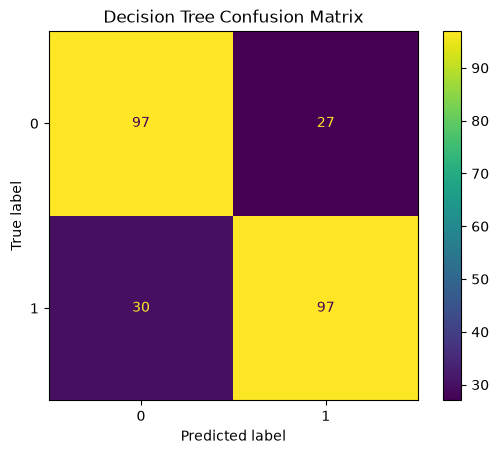

In [279]:
from sklearn.tree import DecisionTreeClassifier
dt_model = DecisionTreeClassifier(
    random_state=42
)

dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

print("Accuracy :", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt))
print("Recall   :", recall_score(y_test, y_pred_dt))
print("F1 Score :", f1_score(y_test, y_pred_dt))

print(classification_report(y_test, y_pred_dt))

ConfusionMatrixDisplay.from_estimator(
    dt_model,
    X_test,
    y_test
)

plt.title("Decision Tree Confusion Matrix")
plt.show()

# Random Forest

Accuracy : 0.8167330677290837
Precision: 0.7956204379562044
Recall   : 0.8582677165354331
F1 Score : 0.8257575757575758
              precision    recall  f1-score   support

           0       0.84      0.77      0.81       124
           1       0.80      0.86      0.83       127

    accuracy                           0.82       251
   macro avg       0.82      0.82      0.82       251
weighted avg       0.82      0.82      0.82       251



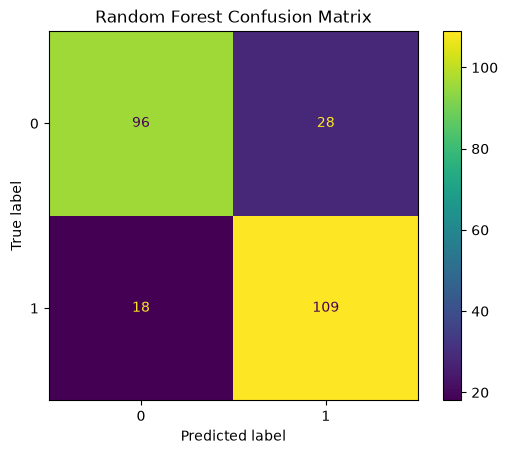

In [280]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("F1 Score :", f1_score(y_test, y_pred_rf))

print(classification_report(y_test, y_pred_rf))

ConfusionMatrixDisplay.from_estimator(
    rf_model,
    X_test,
    y_test
)

plt.title("Random Forest Confusion Matrix")
plt.show()

Three machine learning models were developed to predict whether an individual would seek treatment for a mental health condition. Among the evaluated models, the Random Forest classifier achieved the best overall performance with an accuracy of 81.67%, an F1-score of 82.58%, and an ROC-AUC score of 91.49%, demonstrating excellent discriminative ability. Feature importance analysis revealed that family history of mental illness, work interference, employer mental health support, and awareness of available mental health resources were among the strongest predictors of treatment-seeking behavior.

## ROC-AUC

ROC-AUC Score: 0.9148780797561595


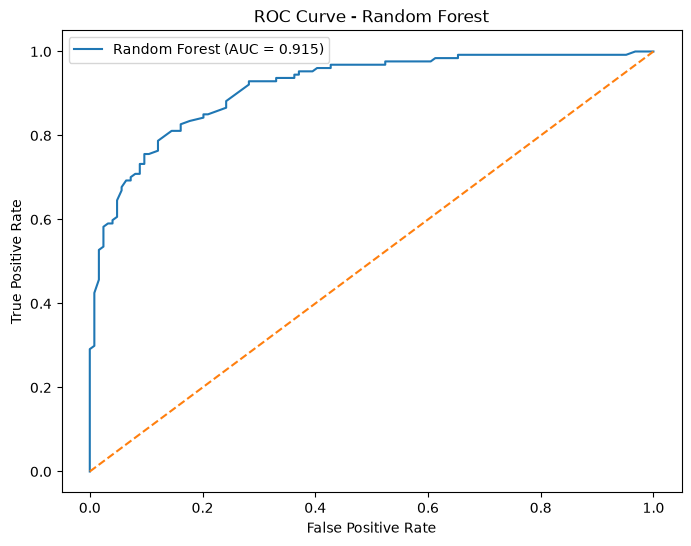

In [281]:
from sklearn.metrics import roc_curve, roc_auc_score
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob_rf)
auc_score = roc_auc_score(y_test, y_prob_rf)

print("ROC-AUC Score:", auc_score)

plt.figure(figsize=(8,6))

plt.plot(fpr, tpr, label=f"Random Forest (AUC = {auc_score:.3f})")

# Random classifier reference line
plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend()

plt.show()

In [282]:
rf_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

rf_importance = rf_importance.sort_values(
    by="Importance",
    ascending=False
)

rf_importance.head(15)

,Feature,Importance
5,"If you have a mental health condition, do you ...",0.284861
0,Age,0.087130
4,Do you have a family history of mental illness?,0.078931
10,Do you know the options for mental health care...,0.049708
2,Country,0.048996
6,How many employees does your company or organi...,0.045239
14,How easy is it for you to take medical leave f...,0.037631
9,Does your employer provide mental health benef...,0.035937
18,Would you be willing to discuss a mental healt...,0.029873
15,Do you think that discussing a mental health i...,0.029463


The Random Forest classifier identified work interference due to mental health as the strongest predictor of treatment-seeking behavior. Respondents who reported that their mental health affected their work were substantially more likely to seek treatment. Other influential predictors included age, family history of mental illness, awareness of employer-provided mental health care, employer mental health benefits, and ease of obtaining medical leave. These findings suggest that both individual factors and workplace support systems play an important role in determining whether employees seek professional mental health treatment.